In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Tự tìm dữ liệu khi chạy từ thư mục gốc dự án hoặc code/.
thu_muc_hien_tai = Path.cwd().resolve()
for thu_muc in (thu_muc_hien_tai, *thu_muc_hien_tai.parents):
    if (thu_muc / "data" / "gia_nha.csv").is_file():
        thu_muc_du_an = thu_muc
        break
else:
    raise FileNotFoundError("Hãy mở notebook từ thư mục dự án hoặc code/, và giữ nguyên data/gia_nha.csv.")

duong_dan_du_lieu = thu_muc_du_an / "data" / "gia_nha.csv"
thu_muc_hinh = thu_muc_du_an / "figures"
thu_muc_hinh.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv(duong_dan_du_lieu)
nhom_lon = df[df["dien_tich"] > 100]

print(len(nhom_lon))
print(nhom_lon["gia"].mean())

10
8.962


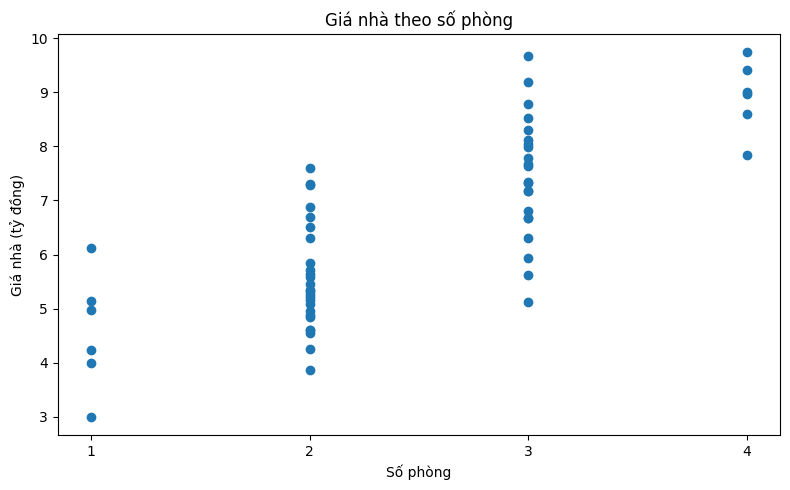

Nhận xét: Nhà có nhiều phòng hơn thường có giá cao hơn, nhưng giá vẫn dao động giữa các căn có cùng số phòng.


In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["so_phong"], df["gia"])
plt.xlabel("Số phòng")
plt.ylabel("Giá nhà (tỷ đồng)")
plt.title("Giá nhà theo số phòng")
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.savefig(thu_muc_hinh / "bai2.png", dpi=150)
plt.show()
print("Nhận xét: Nhà có nhiều phòng hơn thường có giá cao hơn, nhưng giá vẫn dao động giữa các căn có cùng số phòng.")

w = -0.037858
b = 6.983593


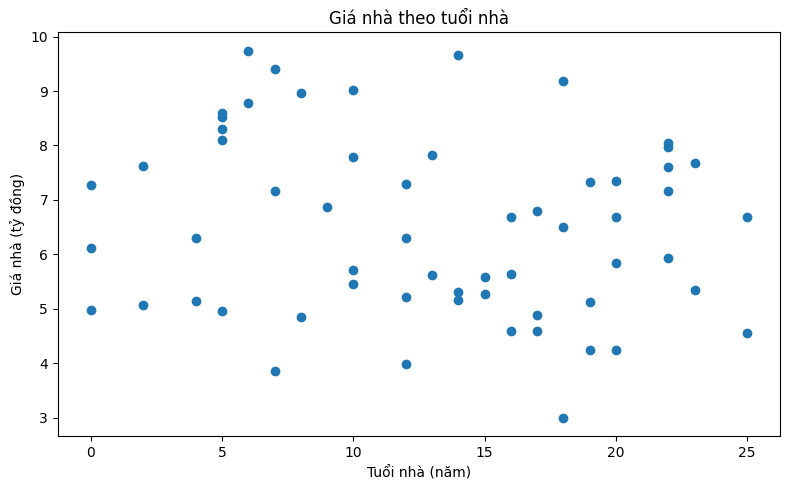

Nhận xét: w âm, nghĩa là theo đường hồi quy, khi tuổi nhà tăng 1 năm thì giá dự đoán giảm khoảng 0,037858 tỷ đồng.
Một cách giải thích hợp lý là nhà cũ thường xuống cấp nên giá có xu hướng thấp hơn; tuy nhiên, dữ liệu này chưa chứng minh tuổi nhà là nguyên nhân làm giá giảm.
Các điểm phân tán rộng, không bám sát một đường thẳng: quan hệ tuyến tính giữa tuổi nhà và giá khá yếu, nên chỉ dùng tuổi nhà để dự đoán giá sẽ kém chính xác.
Hệ số có dấu đúng chưa đủ để kết luận hai đại lượng có quan hệ chặt; w chỉ mô tả xu hướng trung bình trong mẫu và giá còn phụ thuộc vào những yếu tố khác như diện tích, số phòng.


In [4]:
x = df["tuoi_nha"]
y = df["gia"]

x_tb = x.mean()
y_tb = y.mean()
w = ((x - x_tb) * (y - y_tb)).sum() / ((x - x_tb) ** 2).sum()
b = y_tb - w * x_tb

print(f"w = {w:.6f}")
print(f"b = {b:.6f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.xlabel("Tuổi nhà (năm)")
plt.ylabel("Giá nhà (tỷ đồng)")
plt.title("Giá nhà theo tuổi nhà")
plt.tight_layout()
# Lưu hình trước khi hiển thị để tránh xuất ra ảnh trắng.
plt.savefig(thu_muc_hinh / "bai3.png", dpi=150)
plt.show()

print("Nhận xét: w âm, nghĩa là theo đường hồi quy, khi tuổi nhà tăng 1 năm thì giá dự đoán giảm khoảng 0,037858 tỷ đồng.")
print("Một cách giải thích hợp lý là nhà cũ thường xuống cấp nên giá có xu hướng thấp hơn; tuy nhiên, dữ liệu này chưa chứng minh tuổi nhà là nguyên nhân làm giá giảm.")
print("Các điểm phân tán rộng, không bám sát một đường thẳng: quan hệ tuyến tính giữa tuổi nhà và giá khá yếu, nên chỉ dùng tuổi nhà để dự đoán giá sẽ kém chính xác.")
print("Hệ số có dấu đúng chưa đủ để kết luận hai đại lượng có quan hệ chặt; w chỉ mô tả xu hướng trung bình trong mẫu và giá còn phụ thuộc vào những yếu tố khác như diện tích, số phòng.")


In [5]:
X = df[["dien_tich", "so_phong"]]
y = df["gia"]
X_hoc, X_kiem_tra, y_hoc, y_kiem_tra = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mo_hinh = LinearRegression()
mo_hinh.fit(X_hoc, y_hoc)
gia_du_doan = mo_hinh.predict(X_kiem_tra)
r2_hai_bien = r2_score(y_kiem_tra, gia_du_doan)

print(f"Tập học: {len(X_hoc)} căn; tập kiểm tra: {len(X_kiem_tra)} căn.")
print(f"R2 của mô hình diện tích và số phòng: {r2_hai_bien:.4f}")
print(f"So với R2 = 0.9622, R2 tăng {r2_hai_bien - 0.9622:.4f}.")
print("Nhận xét: Thêm số phòng có ích trên lần chia này vì R2 tăng nhẹ, nhưng mức cải thiện không lớn.")
print("Vì tập kiểm tra chỉ có 12 căn, cần đánh giá thêm trên các lần chia khác trước khi kết luận lợi ích này ổn định.")


Tập học: 48 căn; tập kiểm tra: 12 căn.
R2 của mô hình diện tích và số phòng: 0.9698
So với R2 = 0.9622, R2 tăng 0.0076.
Nhận xét: Thêm số phòng có ích trên lần chia này vì R2 tăng nhẹ, nhưng mức cải thiện không lớn.
Vì tập kiểm tra chỉ có 12 căn, cần đánh giá thêm trên các lần chia khác trước khi kết luận lợi ích này ổn định.


In [6]:
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
so_vong = 200
n = len(x)

# Mỗi lần chạy đều khởi tạo lại w, b và chỉ thay đổi tốc độ học.
for toc_do_hoc in (0.001, 1.02, 0.1, 0.5, 0.9, 0.99, 1.0, 1.01):
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y
        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()
        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    # Tính MSE sau lần cập nhật thứ 200, đúng như mã mẫu.
    mse = (((w * x + b) - y) ** 2).mean()
    print(f"Tốc độ học = {toc_do_hoc:g}; vòng {so_vong}; MSE = {mse:.4f}")

print("Giải thích: Tốc độ học 0.001 tạo bước cập nhật quá nhỏ nên sau 200 vòng vẫn chưa tới cực tiểu, MSE còn cao.")
print("Tốc độ học 1.02 tạo bước quá lớn, nhảy qua cực tiểu rồi ra xa hơn, khiến MSE tăng mạnh và thuật toán phân kỳ.")
print("Với tốc độ học 0.1, 0.5 và 0.9, MSE sau 200 vòng đều xấp xỉ 0.1790.")
print("Trong bài này, x được chuẩn hóa bằng độ lệch chuẩn NumPy (ddof=0), nên ranh giới tốc độ học là 1.")
print("Khoảng 0 < tốc độ học < 1 cho hội tụ; tại 1 thì dao động không giảm; lớn hơn 1 thì phân kỳ.")
print("Gần 1 từ phía dưới, thuật toán vẫn hội tụ nhưng có thể cần hơn 200 vòng: tốc độ 0.99 còn MSE = 0.1928.")


Tốc độ học = 0.001; vòng 200; MSE = 20.2175
Tốc độ học = 1.02; vòng 200; MSE = 290391782.0192
Tốc độ học = 0.1; vòng 200; MSE = 0.1790
Tốc độ học = 0.5; vòng 200; MSE = 0.1790
Tốc độ học = 0.9; vòng 200; MSE = 0.1790
Tốc độ học = 0.99; vòng 200; MSE = 0.1928
Tốc độ học = 1; vòng 200; MSE = 44.8113
Tốc độ học = 1.01; vòng 200; MSE = 122947.0009
Giải thích: Tốc độ học 0.001 tạo bước cập nhật quá nhỏ nên sau 200 vòng vẫn chưa tới cực tiểu, MSE còn cao.
Tốc độ học 1.02 tạo bước quá lớn, nhảy qua cực tiểu rồi ra xa hơn, khiến MSE tăng mạnh và thuật toán phân kỳ.
Với tốc độ học 0.1, 0.5 và 0.9, MSE sau 200 vòng đều xấp xỉ 0.1790.
Trong bài này, x được chuẩn hóa bằng độ lệch chuẩn NumPy (ddof=0), nên ranh giới tốc độ học là 1.
Khoảng 0 < tốc độ học < 1 cho hội tụ; tại 1 thì dao động không giảm; lớn hơn 1 thì phân kỳ.
Gần 1 từ phía dưới, thuật toán vẫn hội tụ nhưng có thể cần hơn 200 vòng: tốc độ 0.99 còn MSE = 0.1928.


In [7]:
def du_doan_gia(dien_tich):
    w = 0.078367
    b = 0.401752
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"Cảnh báo: Diện tích {dien_tich} m² nằm ngoài khoảng dữ liệu "
            "35.5–117.5 m²; dự đoán này là ngoại suy nên cần thận trọng."
        )
    return w * dien_tich + b


for dien_tich in (60, 80, 200):
    gia_du_doan = du_doan_gia(dien_tich)
    print(f"Diện tích {dien_tich} m²: giá dự đoán = {gia_du_doan:.3f} tỷ đồng.")


Diện tích 60 m²: giá dự đoán = 5.104 tỷ đồng.
Diện tích 80 m²: giá dự đoán = 6.671 tỷ đồng.
Cảnh báo: Diện tích 200 m² nằm ngoài khoảng dữ liệu 35.5–117.5 m²; dự đoán này là ngoại suy nên cần thận trọng.
Diện tích 200 m²: giá dự đoán = 16.075 tỷ đồng.
